---
title: "Tutorial 3: Data Visualization (Matplotlib)"
authors:
  - name: Sapolnach Prompiengchai
    affiliations:
      - University of Oxford
  - name: Aarushi Vardhan
    affiliations:
      - University of Toronto / University of Cambridge
---

# Goal

So far, we've learned how to organise and analyse data using NumPy and Pandas.

In this notebook, we'll learn how to **visualise** our data using **Matplotlib**, one of the most widely used plotting libraries in Python.

By the end of this notebook, you should be able to:

- understand which type of plot is appropriate for different types of data,
- create common plots such as histograms, bar plots, scatter plots, line plots, and heatmaps,
- understand the common structure shared by most Matplotlib figures,
- customise figures with titles, axis labels, tick labels, legends, and colour bars,
- and interpret basic visualisations commonly encountered in neuroscience.

Before we begin, let's import the packages we'll be using.

If you haven't installed **Matplotlib** yet, refer back to the previous tutorials on how to install Python packages using `conda install` or `pip install` and/or read the package's offical documentation for installing their packages. 

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Getting Started

Most Matplotlib figures follow the same general pattern:

1. Choose a plot type.
2. Add axis labels.
3. Add a title.
4. Display the figure.

In other words, many figures look something like:

```python
plt.<plot_type>(...)

plt.xlabel(...)
plt.ylabel(...)
plt.title(...)

plt.show()
```

As we work through this notebook, notice that the overall structure stays almost exactly the same. Usually, only the first line changes.

Similar to our previous tutorial, let's use similar participant data from the previous notebook.

In [2]:
participant_data = pd.DataFrame({
    "subject_id": [
        "S001", "S002", "S003", "S004", "S005",
        "S006", "S007", "S008", "S009", "S010",
        "S011", "S012", "S013", "S014", "S015",
        "S016", "S017", "S018", "S019", "S020"
    ],
    "age": [
        23, 27, 31, 35, 29,
        41, 38, 45, 33, 26,
        30, 37, 52, 48, 39,
        28, 44, 36, 50, 42
    ],
    "drug_use": [
        "healthy control", "nicotine", "cocaine", "healthy control", "alcohol",
        "heroin", "amphetamine", "healthy control", "nicotine", "cocaine",
        "healthy control", "alcohol", "heroin", "nicotine", "healthy control",
        "amphetamine", "cocaine", "healthy control", "alcohol", "nicotine"
    ],
    "left_hippocampal_volume": [
        3920, 3815, 3650, 4010, 3885,
        3590, 3715, 3995, 3850, 3745,
        3965, 3820, 3610, 3765, 3910,
        3805, 3675, 3940, 3730, 3845
    ],
    "right_hippocampal_volume": [
        3895, 3790, 3605, 3985, 3860,
        3565, 3690, 3970, 3825, 3720,
        3940, 3795, 3585, 3740, 3885,
        3780, 3650, 3915, 3705, 3820
    ]
})

participant_data.head()

,subject_id,age,drug_use,left_hippocampal_volume,right_hippocampal_volume
0,S001,23,healthy control,3920,3895
1,S002,27,nicotine,3815,3790
2,S003,31,cocaine,3650,3605
3,S004,35,healthy control,4010,3985
4,S005,29,alcohol,3885,3860


# Histogram

Suppose you've just received data from a neuroscience study containing participants of different ages.

One of the first questions you might ask is:

> **How are the participant ages distributed?**

A histogram helps answer this question by showing how many observations fall within different ranges of values.

Histograms are commonly used to visualise the distribution of continuous variables (numerical measurements that can take many possible values), such as:

- age,
- brain volume,
- reaction time,
- cortical thickness,
- or any other numerical measurement.

Let's see an example code plotting a histogram.

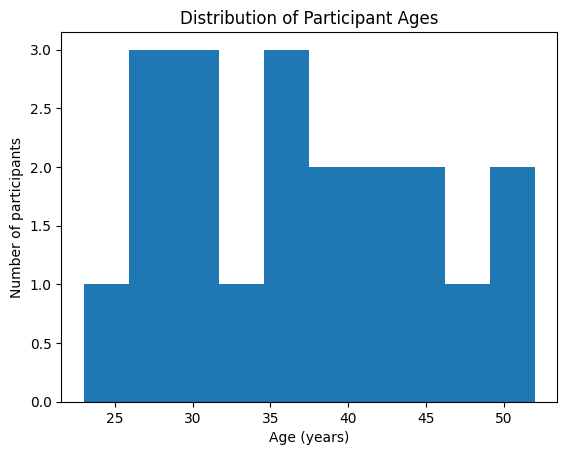

In [3]:
plt.hist(participant_data["age"])

plt.xlabel("Age (years)")
plt.ylabel("Number of participants")
plt.title("Distribution of Participant Ages")

plt.show()

Let's break down the code.

`plt` is short for `matplotlib`, which is similar to how we called numpy methods as np.methods() in our previous tutorial.

```python
plt.hist(participant_data["age"])
```

creates the histogram (`plt.hist`) using the `age` column.

```python
plt.xlabel(...)
```

adds a label to the x-axis.

```python
plt.ylabel(...)
```

adds a label to the y-axis.

```python
plt.title(...)
```

adds a descriptive title.

Finally,

```python
plt.show()
```

displays the completed figure.

Notice that most Matplotlib plots follow this same structure.

### Try it yourself

Create a histogram of:

- `left_hippocampal_volume`
- `right_hippocampal_volume`

Then:

- change the title,
- change the x-axis label,
- change the y-axis label.

# Bar Plot

Sometimes we're interested in **categories** rather than continuous numerical values.

For example, suppose we want to know:

> **How many participants belong to each drug-use category?**

Unlike a histogram, which groups numerical values into ranges, a **bar plot** compares the counts of different categories.

Before creating the plot, let's first count how many participants belong to each category. Here, we can use a pandas method called `pd.value_counts()`. 

In [4]:
drug_counts = participant_data["drug_use"].value_counts()

drug_counts

drug_use
healthy control    6
nicotine           4
cocaine            3
alcohol            3
heroin             2
amphetamine        2
Name: count, dtype: int64

The `value_counts()` function counts how many times each category appears in the column.

We can now visualise these counts using a bar plot.

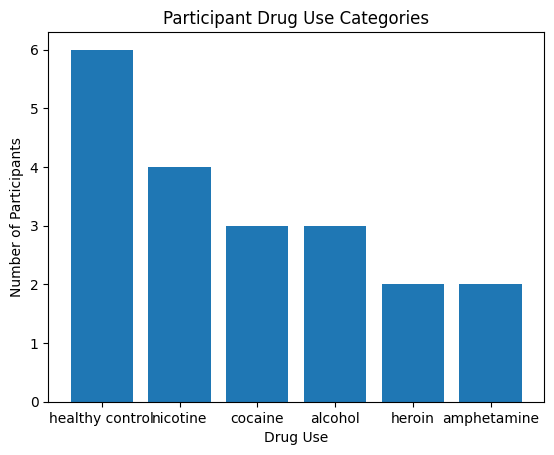

In [5]:
plt.bar(drug_counts.index, drug_counts.values)

plt.xlabel("Drug Use")
plt.ylabel("Number of Participants")
plt.title("Participant Drug Use Categories")

plt.show()

Again, notice that the plotting structure is almost identical to the histogram.

Only the first line has changed:

```python
plt.bar(...)
```

Everything else—axis labels, title, and `plt.show()`—remains the same.

Let's break down the first line:

```python
plt.bar(drug_counts.index, drug_counts.values)
```

A bar plot needs two pieces of information:

- the labels to display on the **x-axis**,
- and the height of each bar (the **y-values**).

In this example:

```python
drug_counts
```

might look something like:

```text
healthy control    6
nicotine           4
cocaine            3
alcohol            3
amphetamine        2
heroin             2
```

Here:

- the **index** contains the category names:
  - `"healthy control"`
  - `"nicotine"`
  - `"cocaine"`
  - ...

- the **values** contain the corresponding counts:
  - `6`
  - `4`
  - `3`
  - ...

So:

```python
drug_counts.index
```

returns:

```text
Index([
    'healthy control',
    'nicotine',
    'cocaine',
    'alcohol',
    'amphetamine',
    'heroin'
])
```

while

```python
drug_counts.values
```

returns:

```text
array([6, 4, 3, 3, 2, 2])
```

Putting them together:

```python
plt.bar(drug_counts.index, drug_counts.values)
```

tells Matplotlib:

> "Create a bar for each drug-use category, where the height of the bar equals the number of participants in that category."

The remaining lines customise the figure:

```python
plt.xlabel("Drug Use")
```

adds a label to the x-axis.

```python
plt.ylabel("Number of Participants")
```

adds a label to the y-axis.

```python
plt.title("Participant Drug Use Categories")
```

adds a title above the figure.

Finally,

```python
plt.show()
```

displays the completed figure.

# Leveraging GenAI for Data Visualization

Let's look at our bar plot again. Notice how the figure does NOT look great?

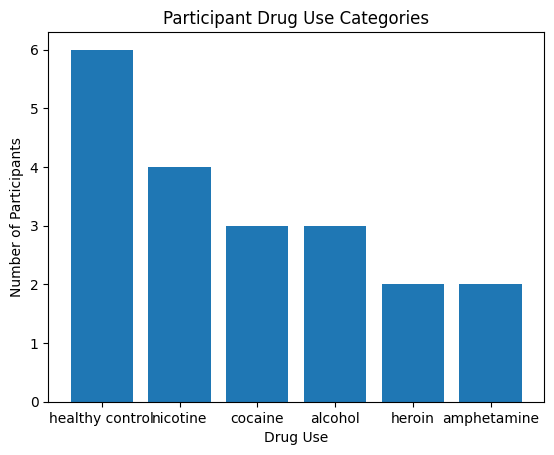

In [7]:
plt.bar(drug_counts.index, drug_counts.values)

plt.xlabel("Drug Use")
plt.ylabel("Number of Participants")
plt.title("Participant Drug Use Categories")

plt.show()

As you begin creating figures, you'll often want to make small improvements—for example:

- rotate overlapping axis labels,
- increase the figure size,
- change the font size,
- add a legend,
- adjust colours,
- or improve the overall appearance.

Generative AI tools such as ChatGPT can be very helpful for these kinds of tasks.

Oftentimes, an effective way to use GenAI is to ask **specific questions** rather than requesting an entirely new figure. This allows it to give concise code that does exactly what you need.

For example, suppose you create the bar plot above and notice that the x-axis labels overlap.

Instead of asking:

> *"Make me a better plot."*

try asking:

> *"I'm using Matplotlib. My x-axis labels overlap in this bar plot. How can I rotate the labels or increase the figure size? Here's my code:"*

and then paste your code.

Because you now understand the basic structure of a Matplotlib figure:

```python
plt.<plot_type>(...)

plt.xlabel(...)
plt.ylabel(...)
plt.title(...)

plt.show()
```

you can ask much more targeted questions and better understand the suggested solutions.


For instance, in this case,  it will likely suggest you to add `plt.xticks()` to rotate the text. 

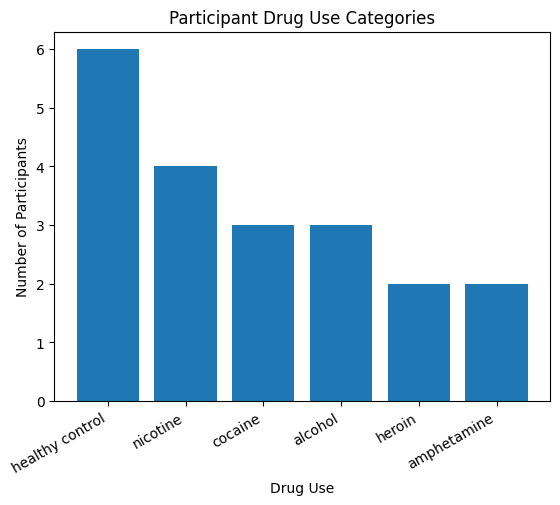

In [6]:
plt.bar(drug_counts.index, drug_counts.values)

plt.xlabel("Drug Use")
plt.ylabel("Number of Participants")
plt.title("Participant Drug Use Categories")

plt.xticks(rotation=30, ha="right")

plt.show()

Much better! 

In general, try to:

- explain what you're trying to achieve,
- describe the specific issue,
- include the relevant code,
- and, if possible, include a screenshot of the figure.

Don't worry if you don't know the correct technical terms. For example, you might not know that the text below the bars is called the **x-axis labels**. That's perfectly fine. You can simply describe what you're seeing (or share a screenshot), and GenAI can often help identify the terminology before suggesting a solution. Though, try learning the terminology as you go along as it may help you leverage GenAI for more complex problems!

The more context you provide, the more useful the suggestions are likely to be.

Also notice how learning the basics of Matplotlib makes GenAI much more useful. For example, if GenAI suggests adding:

```python
plt.xticks(rotation=30, ha="right")
```

you'll hopefully recognise that it belongs alongside the other plotting commands (such as `plt.xlabel()`, `plt.ylabel()`, and `plt.title()`) and understand that it's modifying the appearance of the figure rather than creating a completely new plot. Understanding the overall structure of your code makes it much easier to interpret and adapt the suggestions that GenAI provides.

Remember that GenAI works best as a programming assistant, not as a replacement for understanding the code yourself. Having a solid grasp of the basics makes it much easier to understand the suggestions you receive and decide whether they are appropriate for your problem.

# Scatter Plot

Suppose we're interested in how the brain changes with age.

One possible research question is:

> **Do older participants tend to have smaller hippocampal volumes?**

To begin answering this question, we first need to visualise the relationship between two continuous variables:

- **Age**
- **Left hippocampal volume**

A **scatter plot** is designed for this purpose.

Unlike a histogram (which visualises the distribution of one variable) or a bar plot (which compares categories), a scatter plot shows the relationship between **two numerical variables**.

Each point represents **one participant**.

- The x-coordinate corresponds to one variable (Age).
- The y-coordinate corresponds to another variable (Left Hippocampal Volume).

If a relationship exists, we may begin to see a pattern in how the points are distributed. Let's use `plt.scatter` to generate our scatter plot

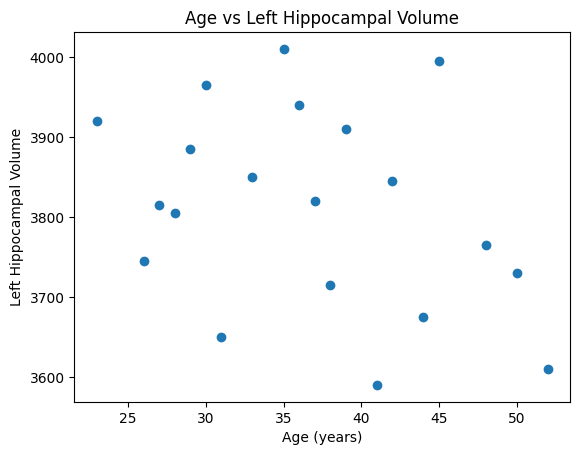

In [8]:
plt.scatter(
    participant_data["age"],
    participant_data["left_hippocampal_volume"]
)

plt.xlabel("Age (years)")
plt.ylabel("Left Hippocampal Volume")
plt.title("Age vs Left Hippocampal Volume")

plt.show()

Let's break down the first line:

```python
plt.scatter(
    participant_data["age"],
    participant_data["left_hippocampal_volume"]
)
```

A scatter plot requires **two variables**:

- the first variable becomes the **x-axis**,
- the second variable becomes the **y-axis**.

Here:

- `participant_data["age"]` determines the horizontal position of each point.
- `participant_data["left_hippocampal_volume"]` determines the vertical position.

Since both columns contain one value for every participant, Matplotlib pairs them together automatically. For example:

| Participant | Age | Left Hippocampal Volume |
|-------------|----:|------------------------:|
| S001 | 23 | 3920 |
| S002 | 27 | 3815 |
| S003 | 31 | 3650 |

becomes three points on the figure.

As before, the remaining lines simply add axis labels, a title, and display the completed figure.

## Try it yourself

Create a scatter plot using:

- `age` vs `right_hippocampal_volume`
- `left_hippocampal_volume` vs `right_hippocampal_volume`

Then:

- change the title,
- change the axis labels,
- make the figure larger using `plt.figure(figsize=(...))`.

## Looking Ahead

Although a scatter plot helps us **visualise** a relationship, it does not tell us how strong that relationship is or whether it is statistically meaningful.

For macroscale connectomics (human neuroimaging), we'll learn how to answer questions such as:

- Is there a significant relationship between behavioural data (such as age) and brain data?
- How strong is the relationship?
- Can we fit a line that summarises the trend?
- Can we adjust for other variables such as sex or education?

To answer these questions, we'll introduce concepts such as:

- **correlation**,
- **linear regression**,
- and **multiple linear regression**.

For now, the scatter plot gives us an important first step: it lets us explore our data visually before applying statistical models.

# Line Plot

Suppose we've extracted the resting-state fMRI signal from a single brain region.

Rather than asking **how values are distributed** (histogram) or **whether two variables are related** (scatter plot), we now want to ask:

> **How does the signal change over time?**

A **line plot** is designed for visualising measurements that are collected sequentially, such as:

- brain activity over time,
- heart rate over time,
- EEG recordings,
- or any other time series.

In a line plot, neighbouring measurements are connected with lines to make it easier to see how the signal changes.

Let's say we have a timeseries of three brain regions for five timepoints. 

In [ ]:
# Recall NumPy array from Tutorial 2
timeseries = np.array([
    [0.10, 0.20, 0.15, 0.18, 0.22],
    [0.30, 0.35, 0.28, 0.31, 0.29],
    [0.42, 0.39, 0.45, 0.47, 0.44]
])

timeseries

array([[0.1 , 0.2 , 0.15, 0.18, 0.22],
       [0.3 , 0.35, 0.28, 0.31, 0.29],
       [0.42, 0.39, 0.45, 0.47, 0.44]])

Recall from the previous tutorial that:

- each **row** represents one brain region,
- each **column** represents one time point.

Let's visualise the first brain region.

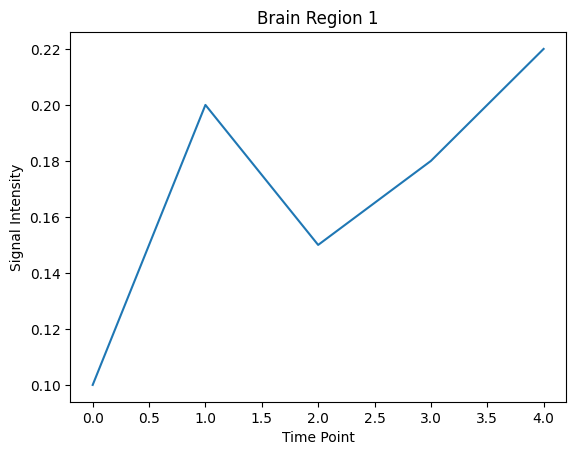

In [11]:
plt.plot(timeseries[0])

plt.xlabel("Time Point")
plt.ylabel("Signal Intensity")
plt.title("Brain Region 1")

plt.show()

Let's break down the first line:

```python
plt.plot(timeseries[0])
```

Here,

```python
timeseries[0]
```

selects the **first row** of the NumPy array, corresponding to the first brain region.

The values:

```text
[0.10, 0.20, 0.15, 0.18, 0.22]
```

are plotted on the y-axis.

Since we did not explicitly provide x-values, Matplotlib automatically uses:

```text
0, 1, 2, 3, 4
```

as the x-axis, representing the time points.

As before, the remaining lines simply add axis labels, a title, and display the completed figure.

### Plotting Multiple Brain Regions

We can also plot multiple brain regions on the same figure.

Each call to `plt.plot()` adds another line.

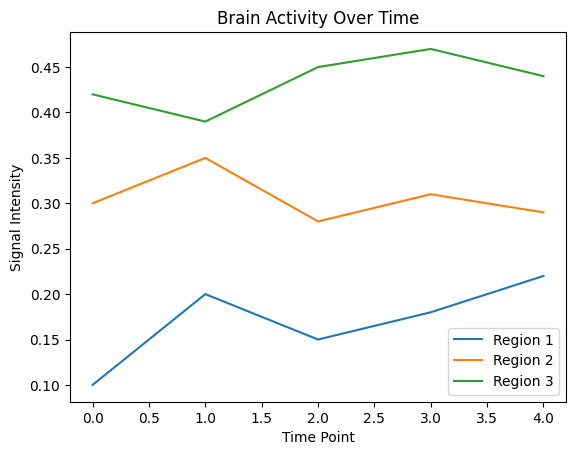

In [12]:
plt.plot(timeseries[0], label="Region 1")
plt.plot(timeseries[1], label="Region 2")
plt.plot(timeseries[2], label="Region 3")

plt.xlabel("Time Point")
plt.ylabel("Signal Intensity")
plt.title("Brain Activity Over Time")

plt.legend()

plt.show()

The function

```python
plt.legend()
```

displays a legend showing which line corresponds to each brain region.

Legends become especially useful when plotting multiple lines on the same figure.

### Try it yourself

- Plot only the second brain region.
- Change the title of the figure.
- Change the axis labels.
- Add a fourth brain region to the `timeseries` array and plot it.
- Plot all brain regions on the same figure with different labels.

# Heatmap

So far, we've visualised our data using:

- histograms,
- bar plots,
- scatter plots,
- and line plots.

However, sometimes our data naturally form a **matrix**, where both the rows and columns carry meaningful information.

For example, in our timeseries data:

- each **row** represents a brain region,
- each **column** represents a time point.

Instead of plotting each brain region separately, we might want to visualise **the entire matrix at once**.

A **heatmap** does exactly that.

Rather than using the height or position of points, a heatmap represents each value using **colour**.

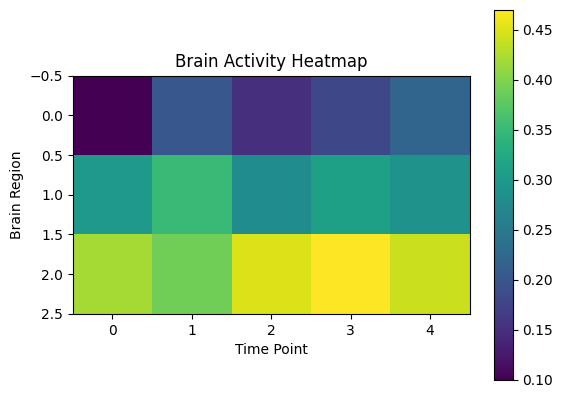

In [13]:
plt.imshow(timeseries)

plt.xlabel("Time Point")
plt.ylabel("Brain Region")
plt.title("Brain Activity Heatmap")

plt.colorbar()

plt.show()

Let's break down the first line:

```python
plt.imshow(timeseries)
```

The function `imshow()` displays a two-dimensional array as an image.

Each value in the array becomes one coloured square.

For our data:

- each **row** corresponds to a brain region,
- each **column** corresponds to a time point,
- and the **colour** represents the signal intensity.

The colour bar on the right shows how colours correspond to numerical values.

As before:

- `plt.xlabel()` labels the x-axis,
- `plt.ylabel()` labels the y-axis,
- `plt.title()` adds a title,
- `plt.colorbar()` displays the colour scale,
- and `plt.show()` displays the completed figure.

However, let's try to improve the figure. For instance, what if we can label the three brain regions on the y axis and incorporate it into the figure. 

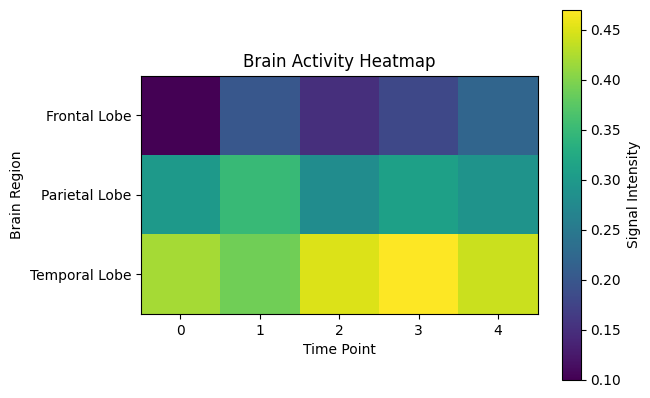

In [16]:
brain_regions = [
    "Frontal Lobe",
    "Parietal Lobe",
    "Temporal Lobe"
]

tick_positions = range(len(brain_regions))

plt.imshow(timeseries)

plt.xlabel("Time Point")
plt.ylabel("Brain Region")
plt.title("Brain Activity Heatmap")

plt.yticks(
    ticks=tick_positions,
    labels=brain_regions
)

plt.colorbar(label="Signal Intensity")

plt.show()

Let's look at the new lines:

```python
tick_positions = range(len(brain_regions))

plt.yticks(
    ticks=tick_positions,
    labels=brain_regions
)
```

Furthermore,

- `len(brain_regions)` returns the number of items in the list.
- `range(n)` creates a sequence of numbers from `0` to `n-1`.

E.g., `range(3)` returns the following sequence: 0, 1, and 2. 

In this example:

```python
brain_regions = [
    "Frontal Lobe",
    "Parietal Lobe",
    "Temporal Lobe"
]
```

there are **3** brain regions.

So:

```python
len(brain_regions)
```

returns:

```text
3
```

and therefore:

```python
range(len(brain_regions))
```

becomes:

```python
range(3)
```

which corresponds to the positions:

```text
0, 1, 2
```

These are exactly the row positions used by the heatmap.

By default, Matplotlib labels these rows as:

```text
0
1
2
```

However, these numbers don't tell us which brain region each row represents.

The function `plt.yticks()` allows us to replace these numbers with more meaningful labels.

Here, in `plt.yticks(...)`,

- `ticks=tick_positions` tells Matplotlib **which row positions** should receive labels.
- `labels=brain_regions` tells Matplotlib **what text** should appear at those positions.

As a result, the rows are labelled:

```text
Frontal Lobe
Parietal Lobe
Temporal Lobe
```

instead of:

```text
0
1
2
```

This makes the figure much easier to interpret and is a common way to customise scientific figures.